# 최종 미션 — 파이썬 재현 노트북
파일명을 `미션재현_이름.ipynb`로 바꾸고 시작하세요.

## 이 노트북의 사용법 ⚠️ 중요

**코드는 여러분이 직접 씁니다.** 주석으로 "무엇을 해야 하는지"만 안내되어 있습니다.

```python
# [해야 할 일] 결측이 몇 개인지 확인
# [힌트] 표의 정보를 요약해주는 메서드 (교재 2-3장)
# [결과] 어떤 컬럼에 몇 개인지 보여야 함

여기에 코드 작성  ← 이 자리를 채우는 게 여러분의 일
```

### ⚠️ 미션은 스스로 수행합니다

**코드 작성과 분석 판단은 질문 대상이 아닙니다.** 오늘은 심사가 진행되는 날이며, 이 부분이 평가 대상입니다.

| 구분 | 질문 가능 여부 |
|---|---|
| 미션 요구사항·제출 형식이 이해되지 않을 때 | ✅ 질문 가능 |
| 데이터 컬럼의 의미가 이해되지 않을 때 | ✅ 질문 가능 |
| 실행 환경 오류 (파일 업로드, Colab 접속 등) | ✅ 질문 가능 |
| **코드를 어떻게 쓰는지** | ❌ 스스로 해결 |
| **어떤 그래프를 골라야 하는지** | ❌ 스스로 판단 |
| **기준값을 얼마로 정해야 하는지** | ❌ 스스로 판단 |
| **문법 오류·에러 해결** | ❌ 스스로 해결 |

**막혔을 때 찾아볼 자료** (전부 배포되어 있습니다)

| 상황 | 참조 |
|---|---|
| Orange3로는 했는데 코드를 모르겠다 | 교재 **4-9 로제타석** (Orange3 ↔ 파이썬 대응표) |
| 문법이 기억 안 난다 | 교재 **2장** (pandas 4동작) / 어제 실습 노트북 |
| 위젯 조작이 기억 안 난다 | Orange3 매뉴얼 **STEP 1~16** |
| 분석 흐름이 막막하다 | 어제 저녁 관찰 노트북 **Q1~Q6** |

> 💡 **한 번에 완성하려 하지 마세요.** 한 줄 쓰고 실행 → 결과 보고 → 다음 줄. 에러는 정상이며, 에러를 읽고 고치는 것도 평가 대상입니다.

### 📚 출처 메모 (NASA 저장소에서 확인한 내용을 여기에)
```
어떤 실험인가:Experiments on Li-Ion batteries. Charging and discharging at different temperatures. Records the impedance as the damage criterion.
제공 기관: NASA Prognostics Center of Excellence (PCoE)
Citation:(인용)B. Saha and K. Goebel (2007). “Battery Data Set”, NASA Prognostics Data Repository, NASA Ames Research Center, Moffett Field, CA
원본 형식 → 배포 형식:https://phm-datasets.s3.amazonaws.com/NASA/5.+Battery+Data+Set.zip
```

---
## 준비 — 데이터 불러오기
> 이 셀만 완성되어 있습니다. 나머지는 직접 작성하세요.
> 시작 전: 왼쪽 📁 패널에 `battery_M.csv`와 `battery_NASA.csv`를 모두 드래그 업로드!

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
m = pd.read_csv("/content/battery_M_260722.csv")          # PART 1 · 스냅샷
nasa = pd.read_csv("/content/battery_NASA_260722.csv")    # PART 2 · 시계열

print("M   :", m.shape, "  한 행 = 셀 하나")
print("NASA:", nasa.shape, "  한 행 = 셀 하나의 한 사이클")

M   : (30, 9)   한 행 = 셀 하나
NASA: (636, 11)   한 행 = 셀 하나의 한 사이클


---
# PART 1 — M데이터 (스냅샷)
## 필수 재현 ① · 데이터 확인
> Orange3의 **Column Statistics**로 본 것을 코드로 다시 확인합니다.

In [77]:
# ─────────────────────────────────────────────
# [해야 할 일] 데이터의 앞부분을 눈으로 확인
# [힌트] 표의 첫 몇 줄만 보여주는 메서드
# ─────────────────────────────────────────────


In [78]:
# ─────────────────────────────────────────────
# [해야 할 일] 각 컬럼의 타입과 결측(Non-Null) 개수 확인
# [힌트] "출석부 훑기" — 교재 2-3장의 세 버튼 중 두 번째
# [결과] 어떤 컬럼에 결측이 몇 개인지 알 수 있어야 함
# ─────────────────────────────────────────────


# ✏️ 확인한 내용 (발표 3·4장 재료):
#    결측 컬럼:  current_capacity     개수:3개


In [79]:
# ─────────────────────────────────────────────
# [해야 할 일] 수치 컬럼의 요약 통계로 이상한 값 찾기
# [힌트] 세 버튼 중 세 번째. min/max를 유심히 볼 것
# [결과] 물리적으로 불가능한 값이 눈에 띄어야 함
# ─────────────────────────────────────────────

m[m['soh'] > 100]
# ✏️ 이상치: 컬럼 : soh / 값;121.0 / 왜 불가능한가: SOH는 신품 대비 완충 용량 비율(%)이므로 100%를 초과할 수 없음


,cell_id,cycle_count,initial_capacity,current_capacity,soh,internal_resistance,avg_temp,charge_time,batch_no
11,M12,597,2842.8,2561.4,121.0,39.7,31.6,102,2


In [80]:
# ─────────────────────────────────────────────
# [해야 할 일] 이상치를 제외한 데이터를 m_clean 이라는 이름으로 만들기
# [힌트] 조건을 걸어 골라내기 = 마스킹 (교재 1-5, 2-5장)
#        SOH는 100%를 넘을 수 없다
# [결과] print로 제거 전/후 행 수를 비교해 보세요
# ─────────────────────────────────────────────
m_clean = m[m['soh'] <= 100]
print(len(m), "->", len(m_clean))



30 -> 29


## 필수 재현 ② · 최종 판정
> Orange3의 **Select Rows**로 한 선별을 코드로 재현합니다. **두 결과가 같아야 정상입니다.**

In [81]:
final = m_clean[(m_clean['soh'] >= 85) & (m_clean['soh'] <= 100)]  # 예시 기준
print("선별된 셀 수:", len(final))
final[['cell_id', 'soh']]

선별된 셀 수: 26


,cell_id,soh
0,M01,92.0
1,M02,85.5
2,M03,93.5
4,M05,99.0
5,M06,87.3
6,M07,98.2
7,M08,99.0
8,M09,96.4
10,M11,92.3
12,M13,96.3


In [82]:
# ─────────────────────────────────────────────
# [해야 할 일] Orange3 결과와 일치하는지 대조
# ─────────────────────────────────────────────
# ✏️ Orange3 Select Rows의 Data Out 셀 수:    26    개
# ✏️ 파이썬 len(final):                       26    개
# ✏️ 일치? -> 예


---
# 관문 ① · 기준 민감도 ★변별
### "그 기준, 흔들리면 결과가 얼마나 달라지나요?"

기준값 하나로 판정하고 끝내면 평범합니다. **기준이 얼마나 예민한지 수치로** 보여주세요.

In [83]:
# ─────────────────────────────────────────────
# [해야 할 일] 내 기준값을 -3 / 그대로 / +3 으로 바꿔가며
#              각각 몇 개가 통과하는지 표처럼 출력
#
# [생각해볼 것] 같은 코드를 값만 바꿔 3번 쓰는 것보다,
#               값 목록을 만들어 반복시키는 게 낫지 않을까?
#               (어제 배운 for문 — 리스트를 하나씩 꺼내 쓰기)
## 기준값 리스트 생성 (82부터 90까지 2씩 증가)
at_least = [78, 80, 82, 84, 85, 86, 88, 90]

for num in at_least:
    passed = len(m_clean[m_clean['soh'] >= num])
    failed = len(m_clean) - passed
    print(f"soh >= {num}: 통과 {passed}개 / 탈락 {failed}개")
# ─────────────────────────────────────────────
#82%가 기준임.

# ✏️ 발표 7장 문장: "기준을 2씩 높이면 위의 양만큼 탈락했음.
#                    그만큼 예민한 경계이므로 수명 종료의 산업적 표준인 80%이지만 80초반에서는
#                    탈락양이 많지 않았음.84까지는 3개 탈락 이지만 86부터는 6개로 급증함. 그래서 중간값이 85로 잡았음.
#                    86%부터는 탈락 셀이 6개, 88%는 7개, 90%는 10개로 과도하게 급증함.
#                    따라서 '출하 품질 확보'와 '수율(26개 합격)'을 모두 잡을 수 있는
#                    가장 적절한 타협점이 바로 85%라고 생각했음.""


soh >= 78: 통과 29개 / 탈락 0개
soh >= 80: 통과 29개 / 탈락 0개
soh >= 82: 통과 28개 / 탈락 1개
soh >= 84: 통과 26개 / 탈락 3개
soh >= 85: 통과 26개 / 탈락 3개
soh >= 86: 통과 23개 / 탈락 6개
soh >= 88: 통과 22개 / 탈락 7개
soh >= 90: 통과 19개 / 탈락 10개


In [84]:
# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 내 기준 경계에 아슬아슬하게 걸린 셀 찾기:
# 기준값(85%) ±2%p 범위 (83% 이상 ~ 87% 이하) 셀 골라내기
boundary_cells = m_clean[(m_clean['soh'] >= 83) & (m_clean['soh'] <= 87)]
print("경계(83~87%)에 걸린 셀 수:", len(boundary_cells))
boundary_cells[['cell_id', 'soh', 'internal_resistance', 'cycle_count']]
# [힌트] 기준값 ±2 범위에 있는 셀만 골라내면 됩니다 (조건 2개)
# [왜?] "이 셀은 왜 탈락시켰나요?" 질문에 사례로 답할 수 있습니다
#-> 86%부터는 탈락 셀이 6개로 급증하여 수율이 급격히 떨어짐.
# 따라서 수율 손실을 최소화하는 '동일 탈락(3개) 구간'의 최상단 스펙인 85%*를 선택함으로써,
# 수율은 지키면서도 출하 품질(SOH)을 최대한 높게 확보했음.

# 산업계에서 요구하는 배터리팩/모듈의 보증 조건은 최소 수백 사이클 이상 잔존 수명이 유지되어야 함.
# 설명: EOL(80%)까지 잔여 SOH가 단 3%p 남짓(83.1%, 83.5%) 남은 셀은
# 출하 후 수십 사이클 내에 EOL에 도달합니다. 이는 제품 보증 기간(Warranty)을 전혀 충족할 수 없는 상태이므로
# 출하 불가(탈락) 사유가 됩니다.
# ─────────────────────────────────────────────



경계(83~87%)에 걸린 셀 수: 5


,cell_id,soh,internal_resistance,cycle_count
1,M02,85.5,38.4,776
9,M10,83.1,38.6,880
17,M18,85.1,41.5,666
18,M19,85.6,38.7,689
20,M21,83.5,39.0,529


---
# 관문 ② · 결측의 영향 ★변별
### "빈칸을 채운 게 답을 바꾸지 않았나요?"

결측을 평균으로 채우고 넘어가면 놓치는 게 있습니다.

In [85]:
# ─────────────────────────────────────────────
# [해야 할 일 1] 결측이 있던 셀들이 어떤 값을 가졌는지 확인
# [힌트] 결측 여부를 판단하는 메서드가 있습니다 (NaN인가?)
#        그 결과를 마스킹 조건으로 쓰면 결측 행만 골라집니다
# [보고 싶은 것] 그 셀들의 cell_id, soh, internal_resistance
# ─────────────────────────────────────────────
# ✏️ 결측 셀들의 SOH는 합격 경계 근처인가, 확실한 불합격인가?
#     -> 합격 경계 근처와 내부에 있는 값이다.

#** current_capacity가 결측(isna)인 행만 마스킹하여 주요 컬럼 확인
na_cells = m[m['current_capacity'].isna()]
na_cells[['cell_id', 'soh', 'internal_resistance', 'current_capacity']]

,cell_id,soh,internal_resistance,current_capacity
5,M06,87.3,42.8,NaN
17,M18,85.1,41.5,NaN
26,M27,94.4,35.9,NaN


In [86]:
# ─────────────────────────────────────────────
# [해야 할 일 2] 결측을 두 가지 방식으로 처리하고 최종 판정을 비교
#   ⓐ 평균으로 채우기  → 내 기준 적용 → 몇 개 통과?
#   ⓑ 해당 행 제외하기 → 내 기준 적용 → 몇 개 통과?
#
# [힌트] 빈칸 채우기 / 빈칸 있는 행 버리기에 해당하는 메서드가 각각 있습니다
#        (교재 4-9 로제타석의 '결측 채우기' 행 참고)
# [결과] 두 방식의 최종 셀 수를 나란히 출력
# ─────────────────────────────────────────────
# `m_clean`을 결측치가 있는 초기 상태로 다시 생성하여 일관된 비교를 보장합니다.
original_m_clean = m[m['soh'] <= 100].copy()

# ⓐ 평균으로 채우기 후 내 기준(SOH >= 85) 적용
m_fill_temp = original_m_clean.copy() # Use the fresh copy with NaNs
m_fill = m_fill_temp.fillna(m_fill_temp.mean(numeric_only=True))
pass_fill = len(m_fill[(m_fill['soh'] >= 85) & (m_fill['soh'] <= 100)])

# ⓑ 해당 행 제외(버리기) 후 내 기준(SOH >= 85) 적용
m_drop_temp = original_m_clean.copy() # Use the fresh copy with NaNs
m_drop = m_drop_temp.dropna() # This should now correctly drop 3 rows
pass_drop = len(m_drop[(m_drop['soh'] >= 85) & (m_drop['soh'] <= 100)])

# 결과 출력
print(f"ⓐ 평균 채우기 적용 시 통과 셀 수 : {pass_fill}개")
print(f"ⓑ 해당 행 제외 적용 시 통과 셀 수 : {pass_drop}개")

# ✏️ 판정이 달라졌는가? 나는 어느 쪽을 택했고 왜인가:
# **평균으로 행 채우지 않고 물리 공식으로 역산해서 행 채우기**
# current_capacity = (soh * initial_capacity) / 100
calculated_cap = (m_clean['soh'] * m_clean['initial_capacity']) / 100
m_clean.loc[:, 'current_capacity'] = m_clean['current_capacity'].fillna(calculated_cap)
#orange3에서 이 방법 가능한가?
#-> 가능함. orange3에 calculated_cap 칼럼에 나오도록 해놨음.
#** 물론 current_capacity를 직접 채우지는 못함. calculated_cap으로 확인!!


ⓐ 평균 채우기 적용 시 통과 셀 수 : 26개
ⓑ 해당 행 제외 적용 시 통과 셀 수 : 23개


---
# 관문 ③ · 함정 회피 ★변별
### "상관 1위가 정말 원인인가요?"

이 데이터에는 **의도적으로 심어둔 함정**이 있습니다. 순위표만 보면 걸립니다.

In [87]:
# ─────────────────────────────────────────────
# [해야 할 일] 이상치를 "제거하기 전(m)"과 "제거한 후(m_clean)"의
#              SOH 상관 순위를 각각 구해서 비교
#
# [힌트] 상관은 corr() — 단, cell_id는 글자라 계산에서 빼야 합니다
#        특정 열을 빼는 방법: drop(columns=[...])
#        SOH 기준 순위만 보려면 결과에서 'soh' 열을 뽑고 정렬
# [결과] 두 순위표를 나란히 출력해 어떤 변수의 순위가 크게 움직였는지 확인
#-> internal_resistance(내부저항)가 크게 변화했다.
# ─────────────────────────────────────────────
# 1) 이상치 제거 전(m) SOH 상관계수 정렬 (cell_id 제외)
corr_before = m.drop(columns=['cell_id']).corr()['soh'].sort_values(ascending=False)

# 2) 이상치 제거 후(m_clean) SOH 상관계수 정렬 (cell_id 제외)
corr_after = m_clean.drop(columns=['cell_id']).corr()['soh'].sort_values(ascending=False)

# 3) 두 결과를 나란히 데이터프레임으로 출력해서 비교
corr_comparison = pd.DataFrame({
    '이상치 제거 전 (m)': corr_before,
    '이상치 제거 후 (m_clean)': corr_after
})

print("=== SOH 상관계수 순위 비교 ===")
corr_comparison



=== SOH 상관계수 순위 비교 ===


,이상치 제거 전 (m),이상치 제거 후 (m_clean)
avg_temp,-0.216368,-0.336624
batch_no,0.411979,0.598602
charge_time,-0.259754,-0.391908
current_capacity,0.679110,0.991565
cycle_count,-0.210082,-0.325065
initial_capacity,0.027397,-0.341384
internal_resistance,-0.446378,-0.842087
soh,1.000000,1.000000


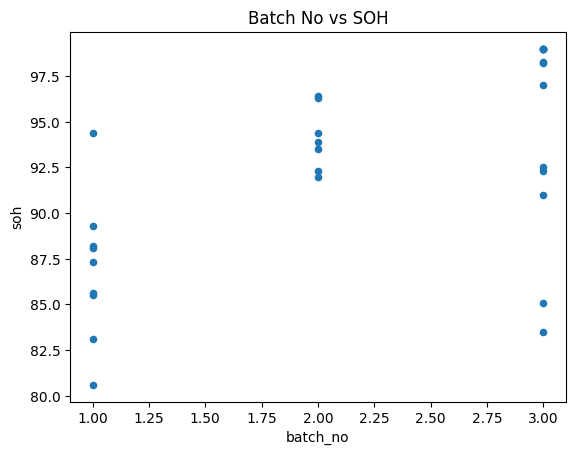

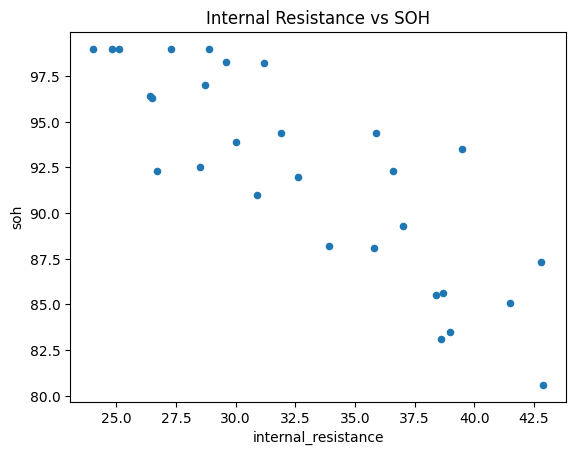

In [88]:
# ─────────────────────────────────────────────
# [해야 할 일] 의심스러운 변수를 산점도로 다시 확인
# [힌트] 산점도는 plot.scatter(x=..., y=...)
# [따져볼 것] 이 변수가 배터리를 늙게 할 "물리적 이유"가 있는가?
#             (예: 생산 배치 번호가 커지면 배터리가 빨리 늙는다? 말이 되는가?)
# ─────────────────────────────────────────────
# 1) 의심스러운 변수 (batch_no) 산점도 확인
m_clean.plot.scatter(x='batch_no', y='soh', title='Batch No vs SOH')
plt.show()

# 2) 물리적 타당 변수 (internal_resistance) 산점도 확인
m_clean.plot.scatter(x='internal_resistance', y='soh', title='Internal Resistance vs SOH')
plt.show()

# ✏️ 상관 1위 변수: internal_resistance   물리적으로 타당한가?배터리가 노화(열화)될수록 화학 반응 저항 및 전극 부식으로 인해
#                                          내부 저항이 지속적으로 상승하는 것은 배터리 공학의 핵심 물리 법칙임.
# ✏️ 함정으로 의심되는 변수: batch_no(생산 배치 번호)   배제 이유: 단순 생산 순서/로트 번호 숫자가 크다고 해서
#                                                                   배터리 SOH가 높아진다는 것은 물리적 상관 관계가 없음
#                                                                  (우연한 상관관계 또는 단순 순서 착시).


---
# PART 2 — NASA 데이터 (시계열)
## 2단계 · 데이터 확인

In [89]:
# ─────────────────────────────────────────────
# [해야 할 일] NASA 데이터의 구조 파악 — 앞부분 + 결측 확인
# [주목] 결측이 있다면 어느 컬럼에, 몇 개나? internal_resistance에 57개
# ─────────────────────────────────────────────
# 1) 데이터 상위 5개 행 눈으로 확인-앞부분
print("=== NASA 데이터 상위 5개 행 ===")
display(nasa.head())

# 2) 각 컬럼의 데이터 타입 및 결측치(Non-Null) 개수 확인-결측 확인
print("\n=== NASA 데이터 요약 정보 (결측치 확인) ===")
nasa.info()

# 3) 컬럼별 결측치 개수 정확히 집계-internal_resistance에 57개
print("\n=== 컬럼별 결측치 개수 ===")
print(nasa.isnull().sum())



=== NASA 데이터 상위 5개 행 ===


,cell_id,cycle_count,ambient_temp,capacity,soh,internal_resistance,avg_temp,max_temp,discharge_time,min_voltage,is_eol
0,B0005,1,24,1.8565,92.8,NaN,32.6,39.0,61.5,2.612,0
1,B0005,2,24,1.8463,92.3,NaN,32.7,39.0,61.2,2.587,0
2,B0005,3,24,1.8353,91.8,NaN,32.6,38.8,60.9,2.652,0
3,B0005,4,24,1.8353,91.8,NaN,32.5,38.8,60.5,2.593,0
4,B0005,5,24,1.8346,91.7,NaN,32.4,38.7,60.5,2.547,0



=== NASA 데이터 요약 정보 (결측치 확인) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cell_id              636 non-null    object 
 1   cycle_count          636 non-null    int64  
 2   ambient_temp         636 non-null    int64  
 3   capacity             636 non-null    float64
 4   soh                  636 non-null    float64
 5   internal_resistance  579 non-null    float64
 6   avg_temp             636 non-null    float64
 7   max_temp             636 non-null    float64
 8   discharge_time       636 non-null    float64
 9   min_voltage          636 non-null    float64
 10  is_eol               636 non-null    int64  
dtypes: float64(7), int64(3), object(1)
memory usage: 54.8+ KB

=== 컬럼별 결측치 개수 ===
cell_id                 0
cycle_count             0
ambient_temp            0
capacity                0
soh                     0

In [90]:
# ─────────────────────────────────────────────
# [해야 할 일 1] 셀마다 사이클 수가 다른지 확인
# [힌트] 셀별로 묶어서(group by) 각 그룹의 최대 사이클을 보면 됩니다
# [왜?] 셀마다 관측 길이가 다르면 비교할 때 주의해야 합니다 (발표 '한계' 재료)
#  -> "NASA 시계열 데이터의 셀별 관측 길이가 B0005~B0007은 168 사이클, B0018은
#      132 사이클로 서로 상이합니다. 이로 인해 특정 사이클 이후 전체 셀을 동일 기간으로
#      비교하거나, EOL 이후 장기 열화 거동을 통일된 기준에서 일반화하는 데 한계가 있습니다."
# ─────────────────────────────────────────────
# 셀별(cell_id)로 묶어서 cycle_count의 최대값(max) 확인
max_cycles = nasa.groupby('cell_id')['cycle_count'].max()

print("=== 셀별 최대 사이클 수 ===")
print(max_cycles)

# ─────────────────────────────────────────────
# [해야 할 일 2 · 관문② 심화] 결측이 어디에 있는지 확인 ★
# [힌트] 결측인 행만 골라낸 뒤, 셀별·사이클별로 어디에 몰려 있는지 보세요
#        (groupby로 묶어 min/max 사이클을 보면 구간이 드러납니다)
# [따져볼 것] 결측이 무작위인가, 특정 구간에 몰려 있는가?
#             몰려 있다면 평균으로 채우는 게 왜 위험한가?
# ─────────────────────────────────────────────
# 1) internal_resistance가 결측(isna)인 행만 추출
nasa_na = nasa[nasa['internal_resistance'].isna()]

# 2) 셀별로 묶어서 결측이 발생한 최소/최대 사이클(구간) 확인
na_summary = nasa_na.groupby('cell_id')['cycle_count'].agg(['min', 'max', 'count'])

print("=== NASA 데이터 셀별 결측 구간 확인 ===")
print(na_summary)

# ✏️ 결측 구간:각 셀의 측정 초기 구간 (1~15 cycle 부근)에 57개 결측이 전부 몰려 있음.
#평균 대체가 위험한 이유:
#  1) 초기 구간 편향: 내부 저항(internal_resistance)은 배터리가 노화될수록
#     (사이클이 진행될수록) 점점 커지는 성질이 있습니다.
#  2) 수치 왜곡: 데이터 전체 평균으로 채워버리면,
#     초기 상태(저항이 원래 낮아야 하는 시점)에 높은 전체 평균 저항값이 입력되어
#    '신품 상태의 초기 저항값이 왜곡(과대평가)'되는 심각한 오류가 발생합니다.
#  3) 결론: 따라서 무작정 전체 평균으로 대체하기보다,
#     초기 구간 선형 보간(Interpolation)이나 셀별 초기 정상 데이터 기반의 추정이 필요합니다.


=== 셀별 최대 사이클 수 ===
cell_id
B0005    168
B0006    168
B0007    168
B0018    132
Name: cycle_count, dtype: int64
=== NASA 데이터 셀별 결측 구간 확인 ===
         min  max  count
cell_id                 
B0005      1   19     19
B0006      1   19     19
B0007      1   19     19


## 3단계 · 열화 곡선 그리기 ★ 오늘의 핵심 그래프
> Orange3에서는 산점도로 봤지만, 파이썬에서는 **진짜 선 그래프**를 그릴 수 있습니다.

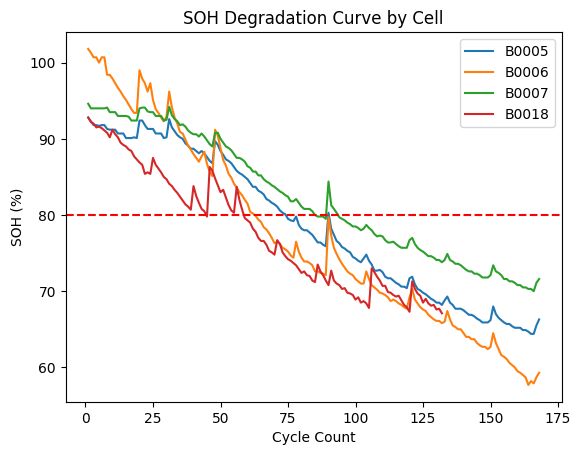

In [91]:
# ─────────────────────────────────────────────
# [해야 할 일] 셀마다 선을 하나씩 그려서, 사이클에 따른 SOH 변화 표시
#
# [설계 힌트]
#   1) 셀별로 데이터를 나눠야 한다 → groupby로 묶으면 (이름, 데이터) 쌍이 나옵니다
#   2) 각 셀마다 선을 하나씩 → plt.plot(x축값, y축값, label=셀이름)
#   3) EOL 기준선 80%를 가로선으로 → plt.axhline(80, color='red', linestyle='--')
#   4) 범례·축 이름 → plt.legend(), plt.xlabel(), plt.ylabel()
#   5) 마지막에 plt.show()
#
# [결과] 왼쪽 위에서 오른쪽 아래로 흘러내리는 곡선 4개 + 빨간 기준선
# ─────────────────────────────────────────────
# 1) 셀별로 묶어서 선 그래프 그리기
for cell_id, group in nasa.groupby('cell_id'):
    plt.plot(group['cycle_count'], group['soh'], label=cell_id)

# 2) EOL 80% 빨간 점선 가로선 추가
plt.axhline(80, color='red', linestyle='--')

# 3) 축 이름 및 범례 설정
plt.xlabel('Cycle Count')
plt.ylabel('SOH (%)')
plt.title('SOH Degradation Curve by Cell')
plt.legend()

# 4) 그래프 출력
plt.show()

# ✏️ 이 그림에서 알게 된 것 한 문장 (발표 8장):
#   -> 4개 셀 모두 사이클 증가에 따라 SOH가 우하향하며,
#      셀별 초기 성능과 열화 속도 차이로 인해 EOL(80%) 도달 시점에 차이가 발생함을 확인했습니다.
#   -> 초기 SOH가 100%에 가까웠던 B0006 셀이 가장 가파른 열화 속도를 보이며 약 50여 사이클 만에
#      EOL(80%)에 두번째로 먼저 도달한 반면, B0005/B0007 셀은 이에 반해 완만하게 버텼습니다.
#      즉, '초기 SOH의 높고 낮음'보다 '열화 기울기(속도)'가 실제 배터리 수명을 결정하는 핵심 요인임을 확인했습니다."

In [92]:
# ─────────────────────────────────────────────
# [해야 할 일] 각 셀이 몇 번째 사이클에 EOL(SOH 80% 미만)에 도달했는지
# [힌트] EOL 여부를 나타내는 컬럼이 이미 있습니다 (is_eol)
#        그 값이 1인 행만 고른 뒤, 셀별로 묶어서 가장 작은 사이클을 찾으면 됩니다
# [결과] 셀 4개의 EOL 도달 사이클
# ─────────────────────────────────────────────
# 1) is_eol이 1인(EOL 도달) 행만 필터링
eol_cells = nasa[nasa['is_eol'] == 1]

# 2) 셀별로 묶어 가장 처음에 도달한 사이클(최소값) 구하기
first_eol_cycles = eol_cells.groupby('cell_id')['cycle_count'].min()

print("=== 셀별 EOL(SOH 80% 미만) 첫 도달 사이클 ===")
print(first_eol_cycles)

# ✏️ 가장 빨리 죽은 셀: B0006    가장 오래 버틴 셀: B0007     차이: 23 사이클


=== 셀별 EOL(SOH 80% 미만) 첫 도달 사이클 ===
cell_id
B0005    75
B0006    63
B0007    86
B0018    45
Name: cycle_count, dtype: int64


---
# 관문 ④ · 교차 검증 ★변별
### "PART 1의 발견이 PART 2에서도 성립하나요?"

두 데이터를 따로 분석하고 끝내면 절반입니다. **연결**하세요.

In [93]:
# ─────────────────────────────────────────────
# [해야 할 일] PART 1에서 찾은 열화 신호(변수)가
#              NASA 데이터에서도 같은 방향인지 상관으로 확인
#
# [힌트] 두 데이터 각각에서 해당 변수와 soh의 상관계수를 구해 나란히 출력
# [따져볼 것] 방향(+/-)은 같은가? 강도는? 왜 차이가 날까?
# ─────────────────────────────────────────────
# 1) M 데이터(이상치 제거 후 m_clean)에서의 내부 저항 - SOH 상관계수
corr_m = m_clean['internal_resistance'].corr(m_clean['soh'])

# 2) NASA 데이터에서의 내부 저항 - SOH 상관계수
corr_nasa = nasa['internal_resistance'].corr(nasa['soh'])

# 3) 두 상관계수 결과를 나란히 출력하여 비교
print(f"M 데이터 (internal_resistance vs SOH) 상관계수   : {corr_m:.4f}")
print(f"NASA 데이터 (internal_resistance vs SOH) 상관계수 : {corr_nasa:.4f}")


#- 방향성: 두 데이터 모두 음(-)의 상관관계로 방향이 완벽히 일치함.
# 즉, 내부 저항이 증가할수록 SOH가 감소(열화)한다는 공학적 원리가 두 데이터셋 모두에서
# 동일하게 성립함을 교차 검증함.
# 강도 및 차이 이유: NASA 시계열 데이터에서 상관관계의 강도가 더 가파르고 강하게 나타남.
#                    이는 스냅샷 데이터(M)에 비해 NASA 데이터가 한 셀의 전체 수명 주기를 연속 관측(시계열)하여
#                    열화에 따른 내부 저항 상승 누적 효과가 더 명확하게 반영되었기 때문임.
# ✏️ M데이터 상관: -0.8421      NASA 상관: -0.7127
# ✏️ 나의 해석 (발표 9장)
# 1) 방향성 일치 (교차 검증):
#   - 두 데이터 모두 강한 음(-)의 상관관계를 보임.
#   - 배터리가 열화(노화)될수록 내부 저항이 상승한다는 물리적/공학적 법칙이
#     스냅샷 데이터(M)와 시계열 데이터(NASA) 모두에서 동일하게 성립함을 최종 교차 검증함.

# 2) 강도 차이 원인:
#   - M 데이터(-0.8421)가 NASA 데이터(-0.7127)보다 상관관계가 더 가파르게 나온 이유는,
#     M 데이터가 '다양한 셀들의 특정 시점 스냅샷'인 반면 NASA 데이터는
#    '동일 셀의 수명 전체 추세'를 담고 있어 셀별 독자적 열화 곡선의 변동성이 포함되었기 때문임.
#    *열화: 배터리가 시간이 지나면서 물리, 화학적으로 늙고 노화되어 성능이 떨어지는 현상
#    *-> 열화 증상: 용량 감소(새 배터리였을 때 담을 수 있었던 용량이 점점 줄어듬
#                   내부 저항 상승(저항상승 시 에너지 손실 증가. 배터리 발열 현상 및 출력 감소)


M 데이터 (internal_resistance vs SOH) 상관계수   : -0.8421
NASA 데이터 (internal_resistance vs SOH) 상관계수 : -0.7127


In [94]:
# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 셀별로 나눠서 본 상관 vs 전체를 한 덩어리로 본 상관 ★
# [힌트] groupby로 셀을 나눈 뒤, 각 그룹에서 저항-SOH 상관을 구해 비교
# [따져볼 것] 셀마다 값이 크게 다른가? 전체 상관과 차이가 나는가?
#             다르다면 "평균의 함정"일 수 있습니다
# ─────────────────────────────────────────────
#****************************여기서부터 코드******************************
import numpy as np

# ─────────────────────────────────────────────
# 1) 셀별로 나눠서 본 상관 vs 전체를 한 덩어리로 본 상관
# ─────────────────────────────────────────────
# 전체 한 덩어리로 본 저항-SOH 상관계수
total_corr = nasa['internal_resistance'].corr(nasa['soh'])

# 셀별로 그룹화하여 저항-SOH 상관계수 구하기
cell_corrs = nasa.groupby('cell_id').apply(
    lambda group: group['internal_resistance'].corr(group['soh'])
)

print(f"=== 전체 한 덩어리 상관계수 : {total_corr:.4f} ===")
print("\n=== 셀별 저항-SOH 상관계수 ===")
print(cell_corrs)

print("\n" + "="*45 + "\n")

# ─────────────────────────────────────────────
# 2) 셀별 열화 속도(기울기, %/cycle) 비교
# ─────────────────────────────────────────────
degradation_rates = {}

for cell_id, group in nasa.groupby('cell_id'):
    # 결측치 제거 후 사이클 순 정렬
    valid_group = group.dropna(subset=['soh', 'cycle_count']).sort_values('cycle_count')

    # 단순 계산 방식: (첫 SOH - 마지막 SOH) / 총 진행 사이클 수
    first_soh = valid_group['soh'].iloc[0]
    last_soh = valid_group['soh'].iloc[-1]
    total_cycles = valid_group['cycle_count'].iloc[-1] - valid_group['cycle_count'].iloc[0]

    rate_simple = (first_soh - last_soh) / total_cycles

    # polyfit(선형 회귀 기울기) 방식: y = ax + b 에서 기울기 a 구하기 (음수이므로 절대값 변환)
    poly_slope = -np.polyfit(valid_group['cycle_count'], valid_group['soh'], 1)[0]

    degradation_rates[cell_id] = {
        '단순 계산 기울기 (%/cycle)': round(rate_simple, 4),
        'Polyfit 기울기 (%/cycle)': round(poly_slope, 4)
    }

rate_df = pd.DataFrame(degradation_rates).T
print("=== 셀별 열화 속도(기울기) 비교 ===")
print(rate_df)

# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 셀별 열화 속도(기울기) 비교
# [힌트] (첫 SOH - 마지막 SOH) / 사이클 수, 또는 numpy polyfit으로 직선 맞추기
# ─────────────────────────────────────────────

import numpy as np
import pandas as pd

degradation_rates = {}

for cell_id, group in nasa.groupby('cell_id'):
    # 유효 데이터 정렬
    valid_group = group.dropna(subset=['soh', 'cycle_count']).sort_values('cycle_count')

    # 1) 단순 계산: (첫 SOH - 마지막 SOH) / 사이클 수
    first_soh = valid_group['soh'].iloc[0]
    last_soh = valid_group['soh'].iloc[-1]
    total_cycles = valid_group['cycle_count'].iloc[-1] - valid_group['cycle_count'].iloc[0]
    rate_simple = (first_soh - last_soh) / total_cycles

    # 2) Polyfit 선형 회귀 기울기 (1차식 y = ax + b의 기울기 a)
    poly_slope = -np.polyfit(valid_group['cycle_count'], valid_group['soh'], 1)[0]

    degradation_rates[cell_id] = {
        '단순 계산 기울기 (%/cycle)': round(rate_simple, 4),
        'Polyfit 기울기 (%/cycle)': round(poly_slope, 4)
    }

rate_df = pd.DataFrame(degradation_rates).T
print("=== 셀별 열화 속도(기울기) 비교 ===")
print(rate_df)



=== 전체 한 덩어리 상관계수 : -0.7127 ===

=== 셀별 저항-SOH 상관계수 ===
cell_id
B0005   -0.929141
B0006   -0.982485
B0007   -0.961474
B0018   -0.558846
dtype: float64


=== 셀별 열화 속도(기울기) 비교 ===
       단순 계산 기울기 (%/cycle)  Polyfit 기울기 (%/cycle)
B0005               0.1587                 0.1933
B0006               0.2545                 0.2544
B0007               0.1377                 0.1635
B0018               0.1962                 0.1964
=== 셀별 열화 속도(기울기) 비교 ===
       단순 계산 기울기 (%/cycle)  Polyfit 기울기 (%/cycle)
B0005               0.1587                 0.1933
B0006               0.2545                 0.2544
B0007               0.1377                 0.1635
B0018               0.1962                 0.1964


/tmp/ipykernel_474/66722481.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_corrs = nasa.groupby('cell_id').apply(


---
# 4단계 · 결론·한계 메모
발표 9~10장에 쓸 내용을 여기에 정리하세요.

In [95]:
결론 = """
1. [핵심 열화 지표 교차 검증]: 내부 저항(internal_resistance)과 SOH는
   M 데이터(-0.8421) 및 NASA 데이터(-0.7127) 모두에서 강한 음(-)의 상관관계를 나타내어
   배터리 노화 판단의 핵심 물리 지표임을 확인했습니다.
   (음의 상관관계: 반비례 관계임을 나타냄. 상승-감소)
   (-> 서로 다른 조건과 형태를 가진 두 데이터셋 모두에서 동일하게 강한 음(-)의 상관관계가
       나타났기 때문에, 다음 두 가지를 완벽히 증명(교차 검증)한 것임. 내부저항-배터리 수명의 상관관계)

2. [초기 SOH vs 열화 기울기]: 초기 SOH 수치보다 '열화 기울기(속도)'가 실제 수명을 결정합니다.
    B0006 셀은 초기 SOH가 가장 높았으나, 가장 가파른 열화 기울기(0.2544%/cycle)를 보이며
    약 63사이클 만에 EOL(80%)에 두 번째로 빠르게 도달했습니다.
    (-> 열화 기울기= 감소한 SOH/사용한 사이클 수, 초기 SOH가 높아도 열화 기울기가 크면
        빠르게 배터리 성능이 감소함.)

3. [최적 판정 기준 산정]: 수율 유지(26개 합격, 3개 탈락)와 출하 품질 보증을 동시에 충족하는
   최적의 SOH 판정 기준값은 85%입니다.
   (-> SOH >= 84%~85%: 통과 26개 / 탈락 3개 (수율 유지 구간)
       SOH >= 86%: 통과 23개 / 탈락 6개 (탈락률 2배 급증)
       SOH >= 90%: 통과 19개 / 탈락 10개 (수율 붕괴)
       85%까지는 탈락 셀이 3개로 일정하게 유지되어 손실이 최소화되지만
       86%부터는 탈락 셀이 6개 이상으로 급증함. 따라서 수율 방어할 수 있는 마지노선이 85%라고 생각했음.)
"""

한계_3가지 = """
1. [셀별 관측 기간의 상이함]: NASA 데이터의 셀별 최대 사이클(B0005~B0007: 168회 / B0018: 132회)이
   달라 동일 기간 기반의 장기 열화 거동 비교 및 일반화에 한계가 있습니다.

2. [결측치 구간의 편향성]: NASA 데이터의 내부 저항 결측치(57개)가 측정 초기(1~19 사이클)에
   집중되어 있어, 전체 평균으로 대체할 경우 신품 상태의 초기 저항이 과대평가되는 오류가 발생합니다.
   (전체 평균값은 노후화된 후반부의 높은 저항값까지 모두 포함되어 계산된 수치이기 때문임.)
   (초기 내부 저항이 없으므로 평균값으로 대체시 기울기 착시 현상 발생 가능성 있음. 기울기가 완만하거나 반대 가능성)

3. [스냅샷 분석의 제한성]: M 데이터는 단일 시점의 스냅샷 데이터이므로 시간에 따른
   누적 열화 추세나 선형/비선형 변화 거동을 직접 추적하는 데 한계가 있습니다.
   (**스냅샷 데이터: 특정 시점의 상태를 고정해서 기록한 데이터.)
"""

print("=== 분석 결론 ===")
print(결론)
print("\n=== 분석의 한계 3가지 ===")
print(한계_3가지)


=== 분석 결론 ===

1. [핵심 열화 지표 교차 검증]: 내부 저항(internal_resistance)과 SOH는
   M 데이터(-0.8421) 및 NASA 데이터(-0.7127) 모두에서 강한 음(-)의 상관관계를 나타내어
   배터리 노화 판단의 핵심 물리 지표임을 확인했습니다.
   (음의 상관관계: 반비례 관계임을 나타냄. 상승-감소)
   (-> 서로 다른 조건과 형태를 가진 두 데이터셋 모두에서 동일하게 강한 음(-)의 상관관계가
       나타났기 때문에, 다음 두 가지를 완벽히 증명(교차 검증)한 것임. 내부저항-배터리 수명의 상관관계)

2. [초기 SOH vs 열화 기울기]: 초기 SOH 수치보다 '열화 기울기(속도)'가 실제 수명을 결정합니다.
    B0006 셀은 초기 SOH가 가장 높았으나, 가장 가파른 열화 기울기(0.2544%/cycle)를 보이며 
    약 63사이클 만에 EOL(80%)에 두 번째로 빠르게 도달했습니다.
    (-> 열화 기울기= 감소한 SOH/사용한 사이클 수, 초기 SOH가 높아도 열화 기울기가 크면
        빠르게 배터리 성능이 감소함.)

3. [최적 판정 기준 산정]: 수율 유지(26개 합격, 3개 탈락)와 출하 품질 보증을 동시에 충족하는
   최적의 SOH 판정 기준값은 85%입니다.
   (-> SOH >= 84%~85%: 통과 26개 / 탈락 3개 (수율 유지 구간)
       SOH >= 86%: 통과 23개 / 탈락 6개 (탈락률 2배 급증)
       SOH >= 90%: 통과 19개 / 탈락 10개 (수율 붕괴)   
       85%까지는 탈락 셀이 3개로 일정하게 유지되어 손실이 최소화되지만
       86%부터는 탈락 셀이 6개 이상으로 급증함. 따라서 수율 방어할 수 있는 마지노선이 85%라고 생각했음.)


=== 분석의 한계 3가지 ===

1. [셀별 관측 기간의 상이함]: NASA 데이터의 셀별 최대 사이클(B0005~B0007: 168회 / B0

---
## 제출 전 확인

- [ ] **런타임 → 모두 실행** 후 저장 (실행 결과가 남아 있어야 합니다)
- [ ] 필수 재현 ②의 셀 수가 Orange3 결과와 일치
- [ ] 열화 곡선 그래프가 그려졌다
- [ ] 관문 ①~④ 중 시도한 것에 ✏️ 메모를 채웠다
- [ ] 파일명이 `미션재현_이름.ipynb`

> **제출 마감: 23:00** — 파일 → 다운로드 → `.ipynb` 다운로드 후 안내 채널에 업로드

> 완성하지 못한 관문이 있어도 괜찮습니다. **시도한 흔적(코드와 메모)이 남아 있으면 부분 점수**를 받습니다.